### Linear regression and Stochastic Gradient Descent

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.metrics import log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
class SGDRegressor(BaseEstimator):
    def __init__(self, eta=1e-3, n_epochs=3):
        self.eta = eta
        self.n_epochs = n_epochs
        
        # Будем хранить историю ошибки и весов
        self.mse_ = []
        self.weights_ = []

    def _add_ones(self, X):
        """
        Добавляем слева колонку единиц.
        Это нужно, чтобы свободный коэффициент w0
        тоже вошёл в матричное умножение.
        """
        X = np.asarray(X)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X, y):
        X = self._add_ones(X)
        y = np.asarray(y)
        
        # Инициализируем веса нулями
        w = np.zeros(X.shape[1])
        
        # На случай повторного fit очищаем историю
        self.mse_ = []
        self.weights_ = []

        for _ in tqdm(range(self.n_epochs)):
            for i in range(X.shape[0]):
                # Текущее предсказание для одного объекта
                y_pred_i = np.dot(X[i], w)
                
                # Ошибка на одном объекте
                error_i = y[i] - y_pred_i
                
                # Одновременное обновление всех весов
                new_w = w + self.eta * error_i * X[i]
                
                w = new_w.copy()
                
                # Логируем веса и MSE на всём train
                self.weights_.append(w.copy())
                self.mse_.append(mean_squared_error(y, np.dot(X, w)))

        # Берём веса, при которых MSE была минимальной
        best_iter = np.argmin(self.mse_)
        self.w_ = self.weights_[best_iter].copy()
        
        return self

    def predict(self, X):
        X = self._add_ones(X)
        return np.dot(X, self.w_)

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"


In [4]:
data_demo = pd.read_csv(DATA_PATH + "weights_heights.csv")


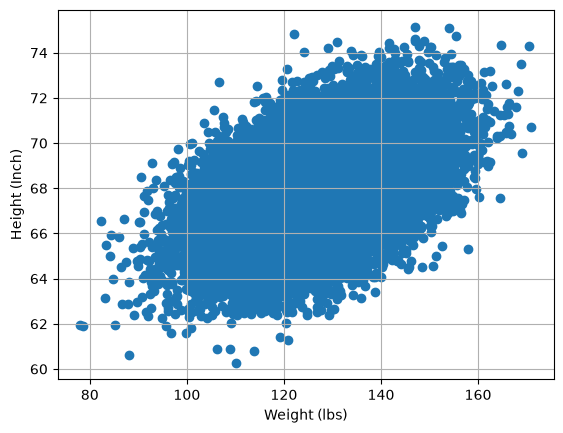

In [5]:
plt.scatter(data_demo["Weight"], data_demo["Height"])
plt.xlabel("Weight (lbs)")
plt.ylabel("Height (Inch)")
plt.grid();

In [6]:
X, y = data_demo["Weight"].values, data_demo["Height"].values


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=17
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape([-1, 1]))
X_valid_scaled = scaler.transform(X_valid.reshape([-1, 1]))

In [10]:
sgd_regressor = SGDRegressor()
sgd_regressor.fit(X_train_scaled, y_train)

100%|██████████| 3/3 [00:28<00:00,  9.33s/it]


,eta,0.001
,n_epochs,3
Name,Type,Value
mse_,list,"[4616.852920655767, 4608.3375526145255, 4598.768933110513, 4589.623842635082, ...]"
w_,"ndarray[float64](2,)","[67.99, 0.94]"
weights_,list,"[array([ 0.069... -0.04162395]), array([ 0.133... -0.13004404]), array([ 0.203... -0.10351219]), array([ 0.271... -0.15870566]), ...]"


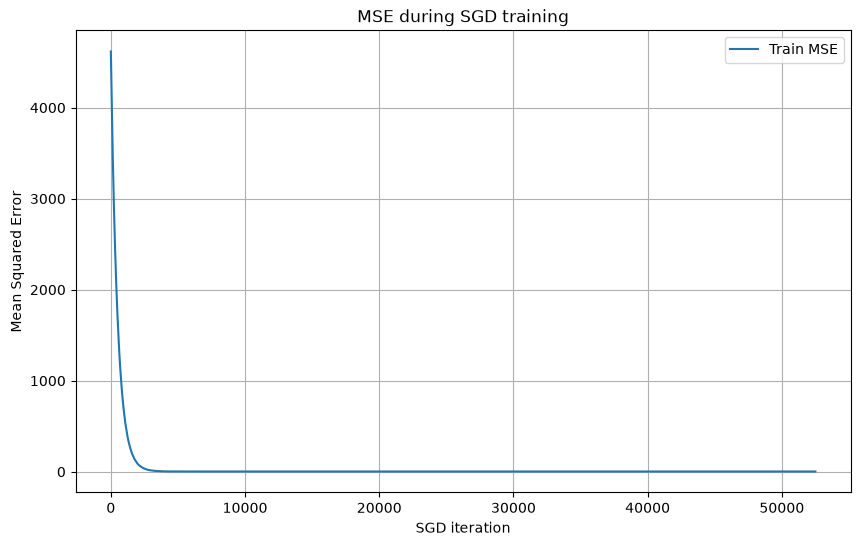

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(sgd_regressor.mse_, label="Train MSE")

plt.xlabel("SGD iteration")
plt.ylabel("Mean Squared Error")
plt.title("MSE during SGD training")

plt.legend()
plt.grid()
plt.show()

In [15]:
sgd_regressor.w_, min(sgd_regressor.mse_)

(array([67.9898497 ,  0.94447605]), 2.7151352406643623)

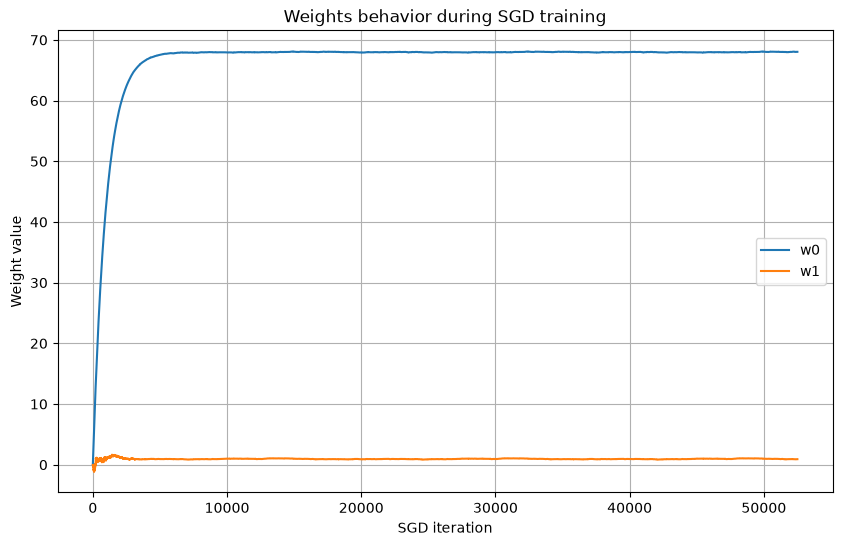

In [18]:
weights = np.array(sgd_regressor.weights_)

plt.figure(figsize=(10, 6))

plt.plot(weights[:, 0], label="w0")
plt.plot(weights[:, 1], label="w1")

plt.xlabel("SGD iteration")
plt.ylabel("Weight value")
plt.title("Weights behavior during SGD training")
plt.legend()
plt.grid()
plt.show()


In [23]:
y_holdout_predictions = sgd_regressor.predict(X_valid_scaled)
sgd_holdout_mse = mean_squared_error(y_valid, y_holdout_predictions)


In [22]:
from sklearn.linear_model import LinearRegression 

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
y_holdout_predictions_lr = lr.predict(X_valid_scaled)
linreg_holdout_mse =mean_squared_error(y_valid, y_holdout_predictions_lr)

In [24]:
try:
    assert (sgd_holdout_mse - linreg_holdout_mse) < 1e-4
    print("Correct!")
except AssertionError:
    print(
        "Something's not good.\n Linreg's holdout MSE: {}"
        "\n SGD's holdout MSE: {}".format(linreg_holdout_mse, sgd_holdout_mse)
    )

Correct!
